In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path
import segmentation_models_pytorch as smp

c:\Users\24bcscs005\Downloads\PB_training_dataSet_shp_file\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_DIR = "dataset/images"
MASK_DIR = "dataset/masks"
CHECKPOINT_PATH = "unet_best_v4.pth"
NUM_CLASSES = 4

In [3]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

mean = checkpoint["mean"]
std = checkpoint["std"]
class_names = checkpoint["class_names"]

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
)

model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

print("✅ Model loaded")
print("Mean:", mean)
print("Std:", std)

C:\Users\24bcscs005\AppData\Local\Temp\ipykernel_55472\715374499.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location="c

✅ Model loaded
Mean: [0.4440578  0.45984784 0.41714284]
Std: [0.13899988 0.13068162 0.13512   ]


Testing sample: 1747


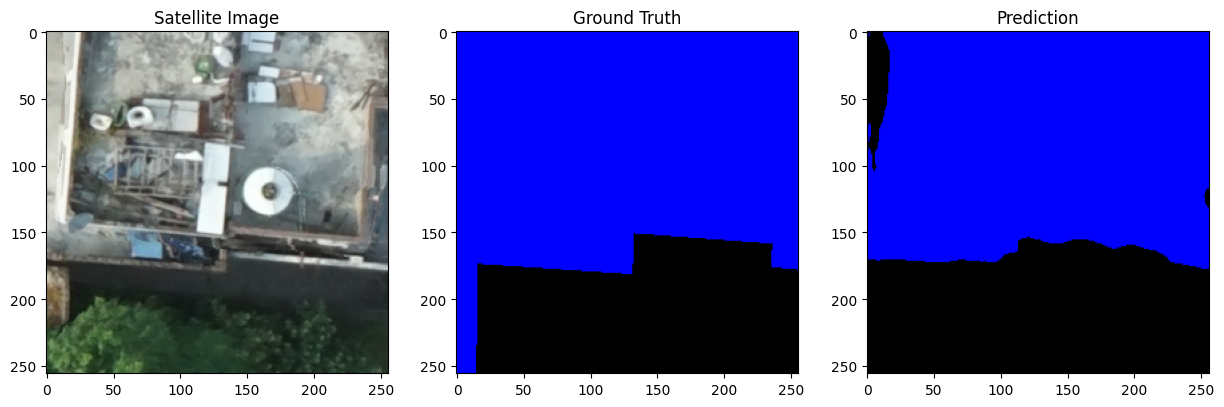

In [77]:
import random, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# 🔥 ensure true randomness
random.seed(time.time())

img_dir = Path("dataset/images")
mask_dir = Path("dataset/masks")

img_files = list(img_dir.glob("*.npy"))

# 🔥 pick random sample
img_path = random.choice(img_files)

idx = img_path.stem.split("_")[1]
mask_path = mask_dir / f"mask_{idx}.npy"

print("Testing sample:", idx)

# load
img = np.load(img_path).astype(np.float32)
mask = np.load(mask_path)

# CHW → HWC (if needed)
if img.shape[0] == 3:
    img = np.transpose(img, (1,2,0))

# 🔥 IMPORTANT: normalize SAME AS TRAINING
img_norm = (img - mean) / (std + 1e-6)

# back to CHW
img_norm = np.transpose(img_norm, (2,0,1))

# tensor
img_tensor = torch.tensor(img_norm, dtype=torch.float32).unsqueeze(0).to(device)

# prediction
with torch.no_grad():
    output = model(img_tensor)

pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()

# 🔥 visualization colors
cmap = np.array([
    [0,0,0],        # background
    [0,0,255],      # blue
    [255,255,0],    # yellow
    [255,0,0]       # red
], dtype=np.uint8)

# original image (for display)
img_show = (img * 255).clip(0,255).astype(np.uint8)

gt_rgb = cmap[mask]
pred_rgb = cmap[pred]

# plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_show)
plt.title("Satellite Image")

plt.subplot(1,3,2)
plt.imshow(gt_rgb)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_rgb)
plt.title("Prediction")

plt.show()